<a href="https://colab.research.google.com/github/zain4cs/student-mental-health-score-predictor/blob/main/Mental_Health_Score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/Student Social Media And Mental Health Impact.csv")
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [4]:
df.duplicated().sum()

np.int64(2)

In [5]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


___________________

**EDA**

**Distribution of Target (Mental_Health_Score)**

In [6]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

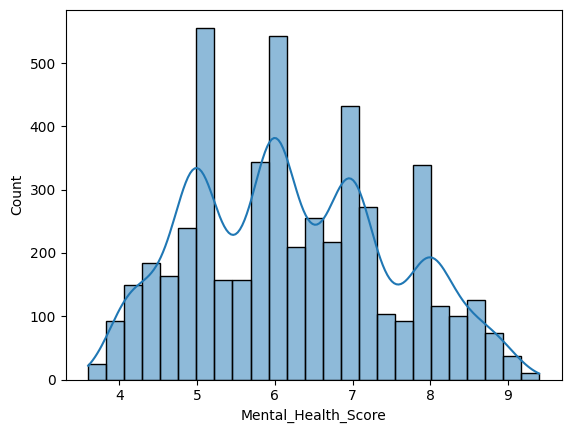

In [7]:
sns.histplot(df['Mental_Health_Score'], kde=True)

***Correlation HEATMAP***

<Axes: >

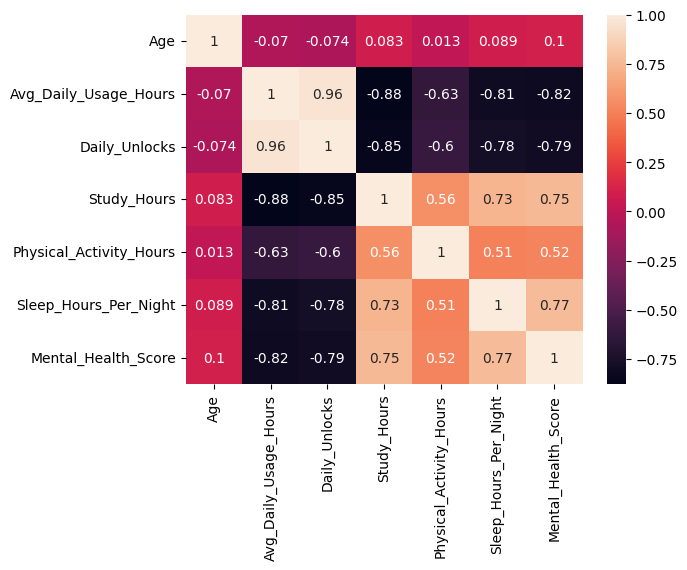

In [8]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [9]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

**Chech Stress_Level VS Mental_Health_Score**

In [10]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

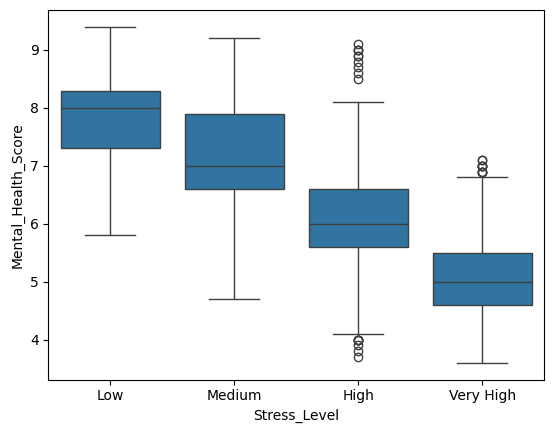

In [11]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x = 'Stress_Level', y = 'Mental_Health_Score', data=df, order=order)

**Daily Usage Hours VS Mental_Health_Score**

In [12]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

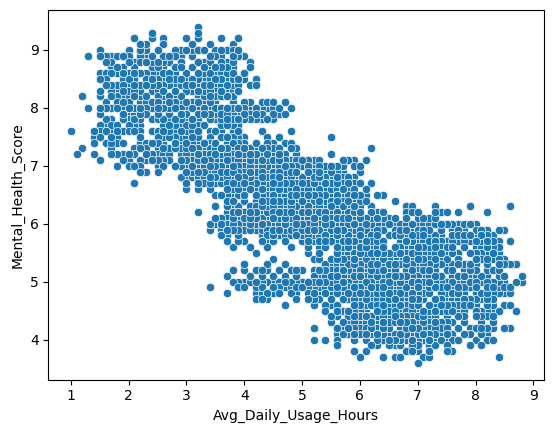

In [13]:
sns.scatterplot(x = 'Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df)

**Sleep_Hours_Per_Night VS Mental_Health_Score**

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

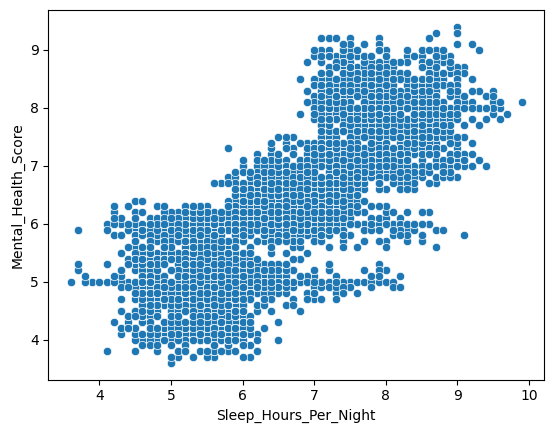

In [14]:
sns.scatterplot(x = "Sleep_Hours_Per_Night", y = "Mental_Health_Score", data=df)

**Most Usage Platform**

In [15]:
df['Most_Used_Platform'].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


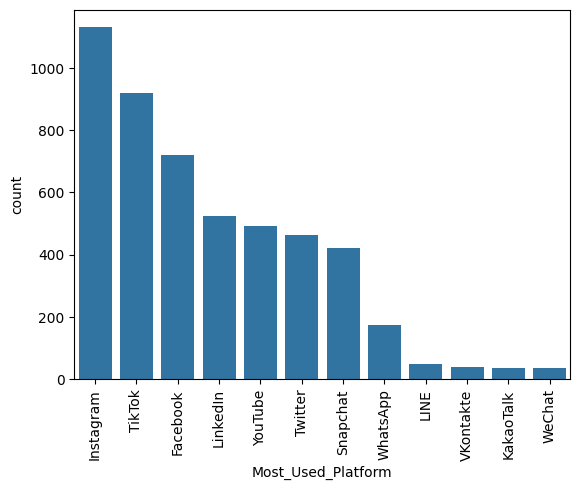

In [16]:
sns.countplot(x = df['Most_Used_Platform'], order=df['Most_Used_Platform'].value_counts().index)
plt.xticks(rotation = 90)
plt.show()

__________________

**Checking Outlier's**

In [17]:
num_features = df.select_dtypes(include='number')
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)

print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


______________________

**Data Cleaning**

In [18]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [19]:
df = df.drop_duplicates()

# Converting Negative Values or Unrealistic Value to Realistic Value

df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

_________________

**Skewness**

In [20]:
num_cols = df.select_dtypes(include='number')
num_cols.skew()

# If Value Near to 0 --> Centralized --- Like (0.1, 0.005)
# Nageive --> Left Skewed --- Like (-1.56)
# Positive (Greater Then 0 )--> Right Skewed --- Like (1.256)

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


________________

**Feature Engineering**

In [21]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [22]:
# Get Top 10 Countries

top_Countries = df['Country'].value_counts().index[: 10].tolist()
top_Countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [23]:
def group_country(country):
  if country in top_Countries:
    return country
  else:
    return 'Other'

In [24]:
df['Group_Country'] = df['Country'].apply(group_country)
df['Group_Country'].value_counts()

,count
Group_Country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


_____________________

**Train_Test_Split**

In [25]:
num_cols.columns

Index(['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')

In [26]:
# Apply Ordinal Encoded Methoed

df['Stress_Level'].value_counts()

,count
Stress_Level,
Very High,1621
High,1439
Medium,1295
Low,643


In [27]:
obj_cols = df.select_dtypes(include='object')
obj_cols.columns

Index(['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Stress_Level', 'Group_Country'],
      dtype='object')

In [28]:
from sklearn.model_selection import train_test_split

skewness_col = ['Study_Hours']
other_num_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours',
                 'Sleep_Hours_Per_Night']

ordinal_col = ['Stress_Level']
nominal_col = ['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform','Purpose_Of_Use', 'Group_Country']

feature_cols = skewness_col + other_num_cols + ordinal_col + nominal_col

X = df[feature_cols]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

__________________________

**IMP**

**Preprocessing Using ColumnsTransformer**

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [30]:
# First Pipline for skewed Column
skewness_pipeline = Pipeline(steps=[
    ('log_transformer', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])


# 2nd Pipline For Numeric Feature
plain_num_pipeline = Pipeline(steps=[
    ('scale', StandardScaler())
])


# 3rd Pipline For Ordinal
ordinal_pipeline = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[['Low','Medium', 'High','Very High']]))
])


# 4th Normal Pipline
nominal_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(transformers=[
    ("Skewness_Pipeline", skewness_pipeline, skewness_col),
    ("Plain_Numeric_Pipeline", plain_num_pipeline, other_num_cols),
    ("Ordinal_Pipeline", ordinal_pipeline, ordinal_col),
    ("Nominal_Pipeline", nominal_pipeline, nominal_col)
])

preprocessor

ColumnTransformer(transformers=[('Skewness_Pipeline',
                                 Pipeline(steps=[('log_transformer',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['Study_Hours']),
                                ('Plain_Numeric_Pipeline',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('Ordinal_Pipeline',
                                 Pipeline(steps=[('ordinal',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('Nominal_Pipeline',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'Country', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use',
                                  'Group_Country'])])

___________________________

**Build Pipeline**

______________________

**Encoding Strategy**

_______________________

# **BaseLine Model**

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [32]:

lr_pipeline = Pipeline(steps=[
    ("Preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_preds_traning = lr_pipeline.predict(X_train)

In [33]:
lr_r2_testing = r2_score(y_test, lr_preds)
lr_r2_traning = r2_score(y_train, lr_preds_traning)

print("Training R2 Score: ", lr_r2_traning)
print("Testing R2 Score: ", lr_r2_testing)

Training R2 Score:  0.7800764399849522
Testing R2 Score:  0.7866987252674537


In [34]:
print("Mean Squared: ", mean_squared_error(y_test, lr_preds))
print("R2 Score: ", r2_score(y_test, lr_preds))
print("Mean Absolute: ", mean_absolute_error(y_test, lr_preds))

Mean Squared:  0.37463747765907285
R2 Score:  0.7866987252674537
Mean Absolute:  0.4787142651068892


_______________

**Random Forest Model**

In [35]:
from sklearn.ensemble import RandomForestRegressor

In [36]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("random forest", RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_pred_traning = rf_pipeline.predict(X_train)


rf_r2_testing = r2_score(y_test, rf_pred)
rf_r2_traning = r2_score(y_train, rf_pred_traning)
rf_mae = mean_absolute_error(y_test, rf_pred)

print(f"Accuracy of Testing Data: {rf_r2_testing}")
print(f"Accuracy of Traning Data: {rf_r2_traning}")
print(f"Mean Absolute Error: {rf_mae}")

Accuracy of Testing Data: 0.9123700007142354
Accuracy of Traning Data: 0.986072771992374
Mean Absolute Error: 0.2849613000000003


________________________

**Hyperparameter Tuning The Random Forest**